<a href="https://colab.research.google.com/github/0IBSIP/0IBSIP/blob/main/Task_2_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Libraries imported successfully!")

Libraries imported successfully!


In [46]:
df = pd.read_csv('/content/ecommerce_retail.csv')

print("Dataset loaded successfully!")
print("Rows and Columns:", df.shape)

df.head()

Dataset loaded successfully!
Rows and Columns: (28030, 25)


,order_id,customer_id,customer_name,product_id,product_name,category,quantity,unit_price_eur,discount_pct,tax_rate,...,shipping_country,shipping_method,delivery_date,delivery_status,warehouse_id,customer_segment,device_type,return_requested,customer_satisfaction_score,created_at
0,ORD-2023000000,CUST-770487,Thomas Meyer,PROD-35898,Samsung Max 8366,Electronics,4.0,248.90,12.03,0.19,...,Deutschland,Standard,2023-04-17,Delivered,WH-FRA,VIP,Tablet,True,NaN,2023-04-03 20:36:00
1,ORD-2023000001,CUST-216739,Sophie Schmidt,PROD-40107,IKEA Pro 4514,Sports,1.0,18.84,4.47,0.19,...,DE,Express,2024-07-10,Shipped,WH-HAM,VIP,mobile,True,3.0,2023-04-08 13:52:00
2,ORD-2023000002,CUST-126225,Max Becker,PROD-74280,Apple Plus 9026,Food,3.0,484.10,27.21,0.19,...,Deutschland,Next Day,2023-06-25,Delivered,WH-MUC,VIP,MOBILE,True,NaN,2023-07-10 21:17:00
3,ORD-2023000003,CUST-877572,Felix Schmidt,PROD-53897,Bosch Pro 2521,Books,3.0,88.23,0.00,0.19,...,GERMANY,Pickup,25/03/2024,Shipped,WH-DRS,Budget,Desktop,False,NaN,2023-11-23 21:55:00
4,ORD-2023000004,CUST-388389,Petra Schneider,PROD-58730,Bosch Max 652,Clothing,1.0,27.45,0.00,0.19,...,Germany,Standard,2023-11-18,delivered,WH-CGN,Regular,MOBILE,False,4.0,2023-07-07 12:44:00


In [47]:
print("Column Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Column Names:
['order_id', 'customer_id', 'customer_name', 'product_id', 'product_name', 'category', 'quantity', 'unit_price_eur', 'discount_pct', 'tax_rate', 'total_amount_eur', 'payment_method', 'payment_status', 'order_date', 'shipping_city', 'shipping_country', 'shipping_method', 'delivery_date', 'delivery_status', 'warehouse_id', 'customer_segment', 'device_type', 'return_requested', 'customer_satisfaction_score', 'created_at']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28030 entries, 0 to 28029
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   order_id                     28030 non-null  object 
 1   customer_id                  28030 non-null  object 
 2   customer_name                28030 non-null  object 
 3   product_id                   28030 non-null  object 
 4   product_name                 28030 non-null  object 
 5   category             

In [48]:
# Remove duplicate rows
df = df.drop_duplicates()

# Convert date column
df['order_date'] = pd.to_datetime(
    df['order_date'],
    errors='coerce'
)

# Remove rows where important customer information is missing
df = df.dropna(
    subset=['customer_id', 'order_date']
)

# Remove invalid values
df = df[
    (df['quantity'] > 0) &
    (df['total_amount_eur'] > 0)
]

print("Cleaned dataset shape:", df.shape)
print("Remaining missing values:")
print(df.isnull().sum())

Cleaned dataset shape: (20910, 25)
Remaining missing values:
order_id                          0
customer_id                       0
customer_name                     0
product_id                        0
product_name                      0
category                          0
quantity                          0
unit_price_eur                    0
discount_pct                      0
tax_rate                          0
total_amount_eur                  0
payment_method                    0
payment_status                    0
order_date                        0
shipping_city                   622
shipping_country                  0
shipping_method                   0
delivery_date                     0
delivery_status                   0
warehouse_id                      0
customer_segment                  0
device_type                       0
return_requested                  0
customer_satisfaction_score    8720
created_at                        0
dtype: int64


In [49]:
# Average Purchase Value
average_purchase_value = df['total_amount_eur'].mean()

print(
    "Average Purchase Value: €",
    round(average_purchase_value, 2)
)

Average Purchase Value: € 1080.13


In [50]:
purchase_frequency = df.groupby(
    'customer_id'
)['order_id'].nunique()

print("Average Purchase Frequency:",
      round(purchase_frequency.mean(), 2))

print("\nPurchase Frequency Statistics:")
print(purchase_frequency.describe())

Average Purchase Frequency: 1.01

Purchase Frequency Statistics:
count    20677.000000
mean         1.011269
std          0.107373
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          3.000000
Name: order_id, dtype: float64


In [51]:
customer_lifetime_value = df.groupby(
    'customer_id'
)['total_amount_eur'].sum()

print("Average Customer Lifetime Value: €",
      round(customer_lifetime_value.mean(), 2))

print("\nCustomer Lifetime Value Statistics:")
print(customer_lifetime_value.describe())

Average Customer Lifetime Value: € 1092.31

Customer Lifetime Value Statistics:
count     20677.000000
mean       1092.305961
std        2398.070767
min          10.010000
25%         509.170000
50%        1011.730000
75%        1515.610000
max      139583.441060
Name: total_amount_eur, dtype: float64


In [52]:
reference_date = df['order_date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg({

    'order_date': lambda x:
        (reference_date - x.max()).days,

    'order_id': 'nunique',

    'total_amount_eur': 'sum'
}).reset_index()

rfm.columns = [
    'customer_id',
    'Recency',
    'Frequency',
    'Monetary'
]

rfm.head()

,customer_id,Recency,Frequency,Monetary
0,CUST-100009,117,1,988.42
1,CUST-100037,1077,1,1848.20
2,CUST-100089,152,1,595.87
3,CUST-100097,880,1,412.16
4,CUST-100193,1068,1,732.69


In [53]:
print("RFM Descriptive Statistics:")

rfm[
    ['Recency', 'Frequency', 'Monetary']
].describe()

RFM Descriptive Statistics:


,Recency,Frequency,Monetary
count,20677.000000,20677.000000,20677.000000
mean,548.012284,1.011269,1092.305961
std,316.801340,0.107373,2398.070767
min,1.000000,1.000000,10.010000
25%,273.000000,1.000000,509.170000
50%,547.000000,1.000000,1011.730000
75%,820.000000,1.000000,1515.610000
max,1096.000000,3.000000,139583.441060


In [54]:
features = [
    'Recency',
    'Frequency',
    'Monetary'
]

X = rfm[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Standardization completed!")
print("Scaled data shape:", X_scaled.shape)

Standardization completed!
Scaled data shape: (20677, 3)


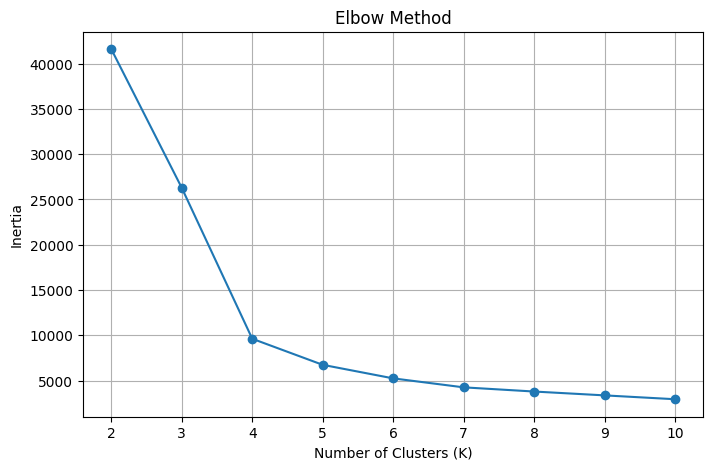

In [55]:
inertia = []

K = range(2, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8, 5))

plt.plot(
    K,
    inertia,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.title('Elbow Method')

plt.grid(True)

plt.show()

In [56]:
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed!")

rfm.head()

K-Means clustering completed!


,customer_id,Recency,Frequency,Monetary,Cluster
0,CUST-100009,117,1,988.42,0
1,CUST-100037,1077,1,1848.20,1
2,CUST-100089,152,1,595.87,0
3,CUST-100097,880,1,412.16,1
4,CUST-100193,1068,1,732.69,1


In [57]:
cluster_profile = rfm.groupby(
    'Cluster'
)[
    ['Recency', 'Frequency', 'Monetary']
].mean().round(2)

print("Cluster Profile:")
cluster_profile

Cluster Profile:


,Recency,Frequency,Monetary
Cluster,,,
0,276.89,1.00,1024.87
1,825.04,1.00,1032.01
2,454.67,1.00,90438.88
3,382.59,2.02,2111.12


In [58]:
cluster_names = {
    0: 'High Value Customers',
    1: 'At Risk Customers',
    2: 'Regular Customers',
    3: 'Potential Customers'
}

rfm['Customer_Type'] = rfm['Cluster'].map(
    cluster_names
)

rfm.head()

,customer_id,Recency,Frequency,Monetary,Cluster,Customer_Type
0,CUST-100009,117,1,988.42,0,High Value Customers
1,CUST-100037,1077,1,1848.20,1,At Risk Customers
2,CUST-100089,152,1,595.87,0,High Value Customers
3,CUST-100097,880,1,412.16,1,At Risk Customers
4,CUST-100193,1068,1,732.69,1,At Risk Customers


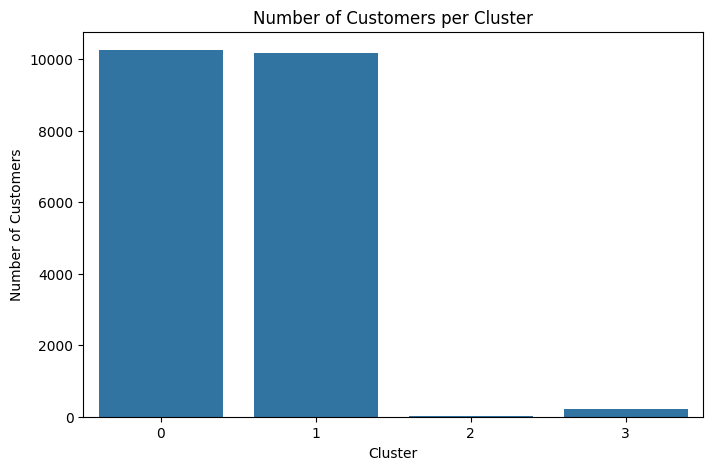

In [59]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.xlabel('Cluster')
plt.ylabel('Number of Customers')

plt.title('Number of Customers per Cluster')

plt.show()

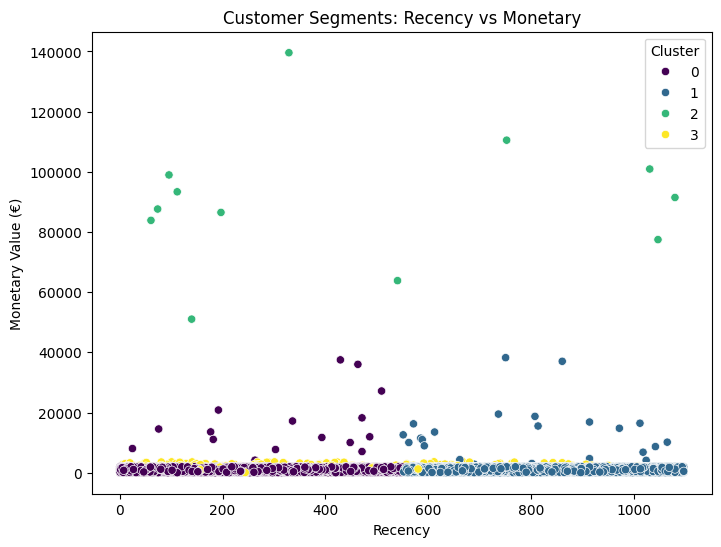

In [60]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='viridis'
)

plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency')
plt.ylabel('Monetary Value (€)')

plt.show()

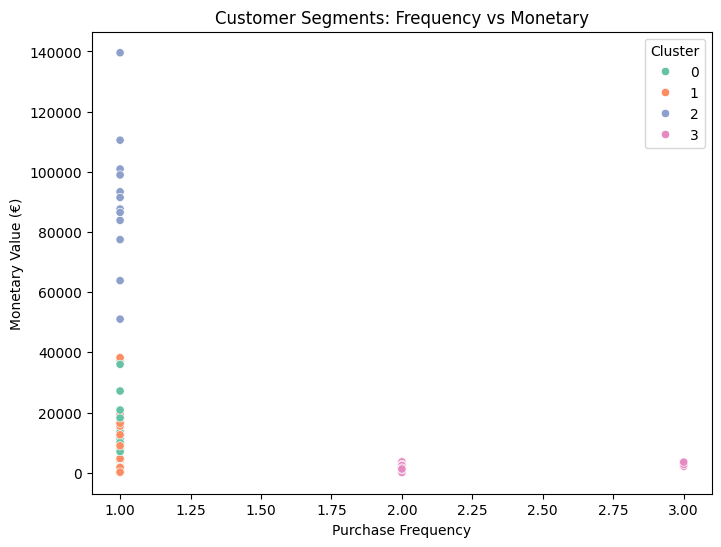

In [61]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set2'
)

plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Purchase Frequency')
plt.ylabel('Monetary Value (€)')

plt.show()

In [62]:
final_summary = rfm.groupby(
    'Cluster'
).agg(

    Customers=('customer_id', 'count'),

    Avg_Recency=('Recency', 'mean'),

    Avg_Frequency=('Frequency', 'mean'),

    Avg_Monetary=('Monetary', 'mean')

).round(2)

final_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,10257,276.89,1.00,1024.87
1,10179,825.04,1.00,1032.01
2,12,454.67,1.00,90438.88
3,229,382.59,2.02,2111.12


## Marketing Insights

### Cluster 0 – High Value Customers
These customers purchase frequently and generate high monetary value.

Marketing Action:
- Offer loyalty rewards
- Provide exclusive discounts
- Give early access to new products
- Focus on customer retention

### Cluster 1 – At Risk Customers
These customers have high recency values, indicating that they have not purchased recently.

Marketing Action:
- Send personalized re-engagement emails
- Provide limited-time offers
- Recommend previously purchased products

### Cluster 2 – Regular Customers
These customers show moderate purchasing frequency and spending.

Marketing Action:
- Encourage repeat purchases
- Offer bundle deals
- Use personalized recommendations

### Cluster 3 – Potential Customers
These customers have potential to become higher-value customers.

Marketing Action:
- Introduce loyalty programs
- Provide first/next purchase incentives
- Use targeted product recommendations

## Conclusion

K-Means clustering was successfully applied to segment the e-commerce customer base using RFM features: Recency, Frequency, and Monetary Value.

The customer data was cleaned and standardized using StandardScaler before clustering. The Elbow Method was used to identify an appropriate number of clusters.

The resulting customer segments represent different purchasing behaviours, such as high-value, regular, potential, and at-risk customers. These segments can help the company develop targeted marketing strategies, improve customer retention, increase repeat purchases, and maximize customer lifetime value.